In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from torch import nn
import torch
import random

In [3]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

out = np.load('training-val-test-data.npz')
th_train = out['th'] #th[0],th[1],th[2],th[3],...
u_train = out['u'] #u[0],u[1],u[2],u[3],...

# data = np.load('test-prediction-submission-file.npz')
data = np.load('hidden-test-prediction-submission-file.npz')
upast_test = data['upast'] #N by u[k-15],u[k-14],...,u[k-1]
thpast_test = data['thpast'] #N by y[k-15],y[k-14],...,y[k-1]
# thpred = data['thnow'] #all zeros

In [4]:
def create_IO_data(u,y,na,nb):
    X = []
    Y = []
    for k in range(max(na,nb), len(y)):
        u_past = u[k-nb:k]
        y_past = y[k-na:k]

        # Trigonometric features of the raw angles
        sin_y = np.sin(y_past)
        cos_y = np.cos(y_past)
        
        X.append(np.concatenate([u_past,sin_y, cos_y]))
        Y.append(y[k])
    return np.array(X), np.array(Y)

In [5]:
na = 5
nb = 5
u_tr, u_val, th_tr, th_val = train_test_split(u_train, th_train, shuffle = False)

Xtrain_u, Ytrain_u = create_IO_data(u_tr, th_tr, na, nb)
Xval_u, Yval_u = create_IO_data(u_val, th_val, na, nb)

# Scaling of variables
X_mean = np.mean(Xtrain_u, axis = 0)
X_std = np.std(Xtrain_u, axis = 0)

Y_mean = np.mean(Ytrain_u, axis = 0)
Y_std = np.std(Ytrain_u, axis = 0)

Xtrain = (Xtrain_u - X_mean)/X_std
Xval = (Xval_u - X_mean)/X_std

Ytrain = (Ytrain_u - Y_mean)/Y_std
Yval = (Yval_u - Y_mean)/Y_std

In [8]:
class Network(nn.Module): 
    def __init__(self, n_in, n_hidden_nodes): 
        super(Network,self).__init__()
        self.lay1 = nn.Linear(n_in, n_hidden_nodes).double()
        self.lay2 = nn.Linear(n_hidden_nodes, n_hidden_nodes).double()
        self.lay3 = nn.Linear(n_hidden_nodes, n_hidden_nodes).double()
        self.lay4 = nn.Linear(n_hidden_nodes, n_hidden_nodes).double()
        self.lay5 = nn.Linear(n_hidden_nodes, 1).double()

    def forward(self,u): 
        # u.shape == (N,10)
        #u = u[:, None]  # Convert u from shape (N,) to (N,1)
        x1 = torch.nn.functional.elu(self.lay1(u)) 
        x2 = torch.nn.functional.elu(self.lay2(x1))
        x3 = torch.nn.functional.elu(self.lay3(x2))
        x4 = torch.nn.functional.elu(self.lay4(x3))
        y = self.lay5(x4)[:, 0] 

        return y

n_hidden_nodes = 64
epochs = 5000 

In [9]:
model = Network(Xtrain.shape[1],n_hidden_nodes) #create the network
    
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3, weight_decay = 1e-5)

Xtrain,Ytrain, Xval, Yval = [torch.as_tensor(x) for x in [Xtrain,Ytrain, Xval, Yval]]

best_val_loss = float('inf')
best_weights = None

for epoch in range(epochs):
    Loss = torch.mean((model(Xtrain)-Ytrain)**2)
    optimizer.zero_grad() 
    Loss.backward()
    optimizer.step()
    
    if epoch%100==0: 
        model.eval()
        with torch.no_grad():
            val_loss = torch.mean((model(Xval) - Yval)**2).item()**0.5
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict()
        
        print(epoch,Loss.item()**0.5)

# 6. Evaluation on Train Set
model.load_state_dict(best_weights)
model.eval()
with torch.no_grad():
    Ytrain_pred_scaled = model(Xtrain).numpy() 

Ytrain_np = (Ytrain.numpy() * Y_std) + Y_mean
Ytrain_pred = (Ytrain_pred_scaled * Y_std) + Y_mean

print('train prediction errors:')
print('RMS:', np.mean((Ytrain_pred-Ytrain_np)**2)**0.5,'radians')
print('RMS:', np.mean((Ytrain_pred-Ytrain_np)**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((Ytrain_pred-Ytrain_np)**2)**0.5/Ytrain_np.std()*100,'%')

 #only select the ones that are used in the example
y_p = thpast_test[:,15-na:]
Xtest = (np.concatenate([upast_test[:,15-nb:], np.sin(y_p), np.cos(y_p)],axis=1) - X_mean)/X_std
Xtest_t = torch.as_tensor(Xtest)

model.eval()
with torch.no_grad():
    Ypredict_scaled = model(Xtest_t).numpy() 
    Ypredict = (Ypredict_scaled * Y_std) + Y_mean
assert len(Ypredict)==len(upast_test), 'number of samples changed!!'


np.savez('hidden-test-prediction-example-submission-file.npz', upast=upast_test, thpast=thpast_test, thnow=Ypredict)

0 1.0011332152096266
100 0.07980370301407726
200 0.046016812962478844
300 0.02787944274525479
400 0.021060307206182658
500 0.01738352944993664
600 0.015074018050927056
700 0.013577626339332344
800 0.012592043709398816
900 0.011911810345709713
1000 0.011408128357606451
1100 0.011009050695798656
1200 0.010674337991506133
1300 0.010382138966727952
1400 0.010119941647233593
1500 0.009880472780825373
1600 0.009766386065718983
1700 0.009536798308153405
1800 0.0093495299292775
1900 0.009637859600503519
2000 0.009157829730460289
2100 0.008984345704878573
2200 0.008833550719966962
2300 0.008864469495269506
2400 0.008784885510756343
2500 0.008617685844666842
2600 0.008483200343986764
2700 0.008362542574806649
2800 0.03507507114737872
2900 0.008473788207935342
3000 0.008298574032148046
3100 0.008173392919592345
3200 0.008067019163539154
3300 0.007972080879246847
3400 0.028130057010256587
3500 0.00813124319659786
3600 0.007973503154601899
3700 0.007865489912866772
3800 0.00777633249574592
3900 0.0

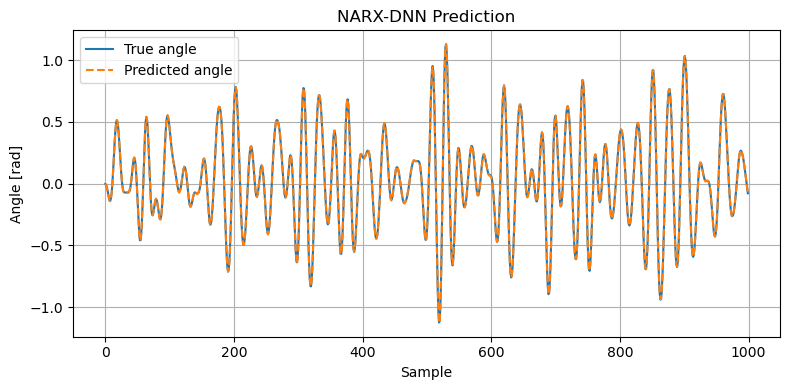

In [16]:
plt.figure(figsize=(8,4))

# Plot only a subset so differences are visible
N = 1000
plt.plot(Ytrain_np[:N], label='True angle')
plt.plot(Ytrain_pred[:N], '--', label='Predicted angle')

plt.xlabel('Sample')
plt.ylabel('Angle [rad]')
plt.title('NARX-DNN Prediction')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('ANN_prediction.png', dpi=300, bbox_inches='tight')
plt.show()